In [1]:
#Force Jupyter to refresh all Python files everytime it imports (this works questionably at best)
%load_ext autoreload 
%autoreload 2

from imports import * #Import all necessary Python modules

from imported import check_imported_modules as imported_modules #Verify that all necessary modules are imported

modules_to_check=['numpy','scipy.stats','astropy.units','matplotlib.pyplot','KapteynClustering'] #List of modules to verify installation

imported_modules(modules_to_check) #Function that runs module installation verification, will output any uninstalled modules and pass if all modules are installed

<unknown>:32: SyntaxWarning: invalid escape sequence '\p'
<unknown>:33: SyntaxWarning: invalid escape sequence '\p'
<unknown>:523: SyntaxWarning: invalid escape sequence '\p'
<unknown>:524: SyntaxWarning: invalid escape sequence '\p'
<unknown>:32: SyntaxWarning: invalid escape sequence '\p'
<unknown>:33: SyntaxWarning: invalid escape sequence '\p'
<unknown>:523: SyntaxWarning: invalid escape sequence '\p'
<unknown>:524: SyntaxWarning: invalid escape sequence '\p'


halo18 clustering data located.


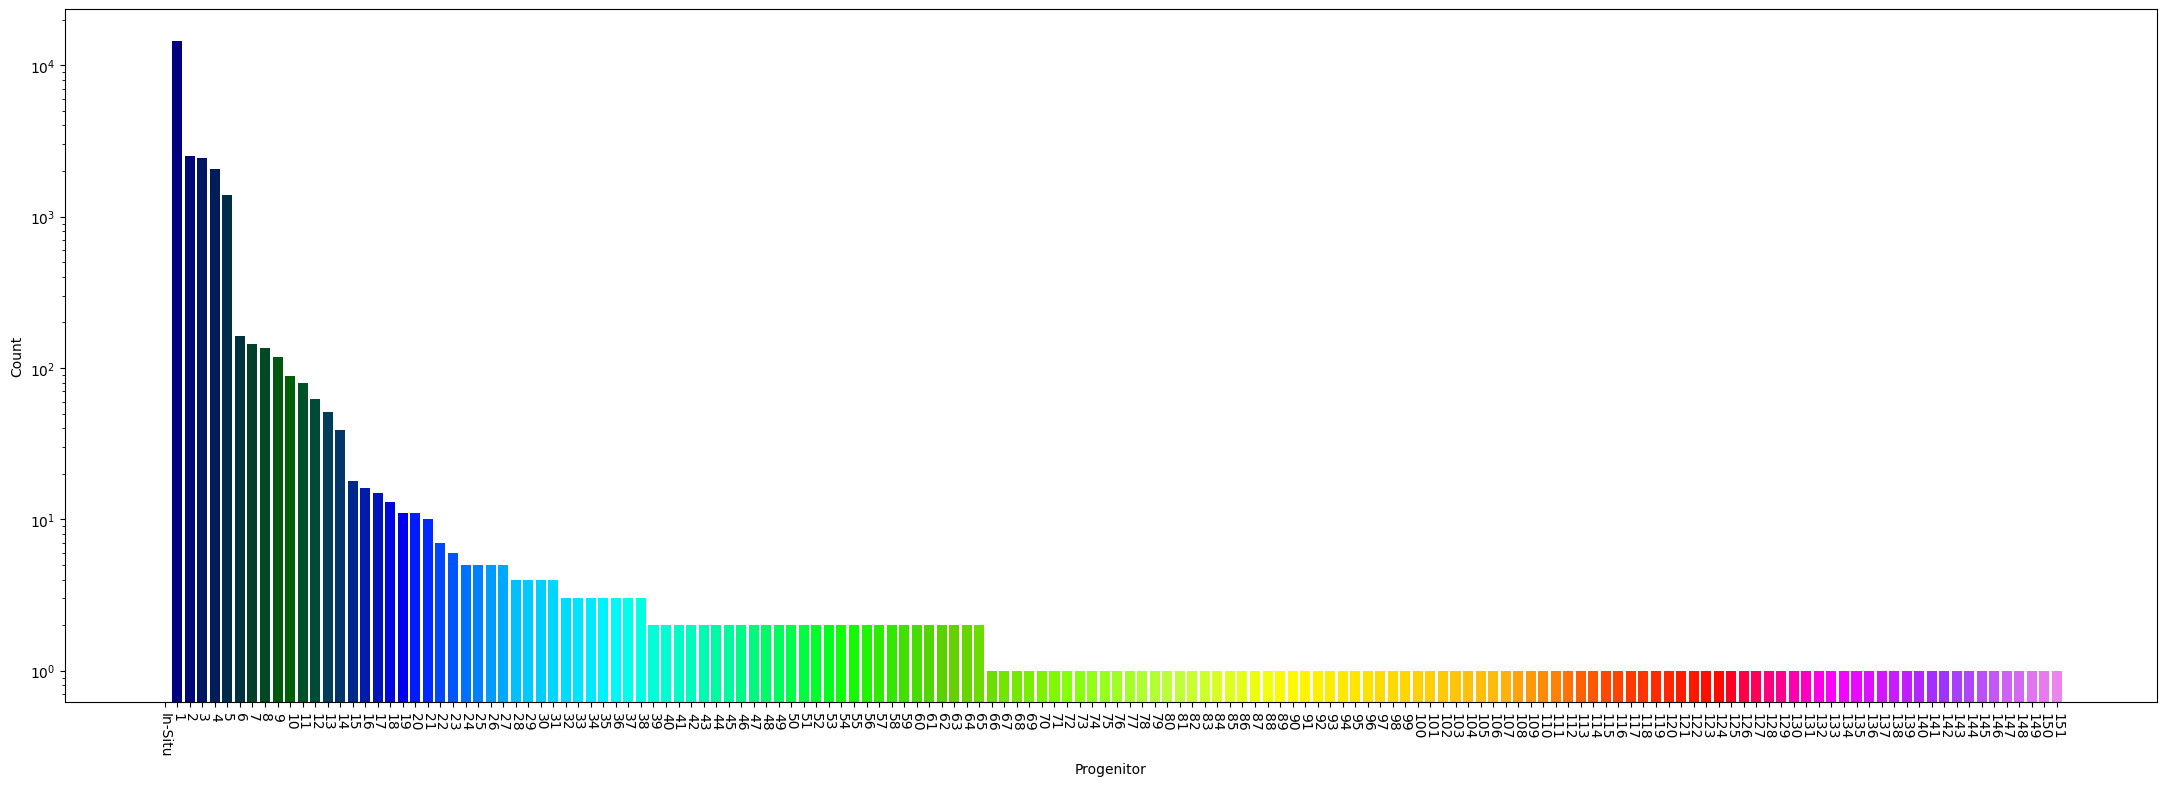

<Figure size 640x480 with 0 Axes>

In [ ]:
import run_clustering as clustering
import plot_generation as plot
import progenitor_analysis as prog

halo='halo18'
lsr_def='8kpc'
vtoomre=False

#clustering.show_load_data_commands(halo,lsr_def,vtoomre)

#clustering.cluster(halo,lsr_def=lsr_def,vtoomre=vtoomre)
#clustering.chemistry_grouping(halo,lsr_def=lsr_def,vtoomre=vtoomre,regen_dist_matrix=True,plots={'cluster_dendrogram':True})

#clustering.chemistry_grouping(halo,lsr_def=lsr_def,vtoomre=vtoomre,regen_dist_matrix=False,plots={'cluster_dendrogram':True})

#plot.clusters(halo,lsr_def=lsr_def,vtoomre=vtoomre,cluster_by='raw')
#plot.clusters(halo,lsr_def=lsr_def,vtoomre=vtoomre,cluster_by='groups')
#plot.clusters(halo,lsr_def=lsr_def,vtoomre=vtoomre,cluster_by='chemistry')
#plot.clusters(halo,lsr_def=lsr_def,vtoomre=vtoomre,cluster_by='progenitor')

#plot.cluster_dendrogram(halo,lsr_def=lsr_def,vtoomre=vtoomre,show_chem=True)

#plot.cluster_only(halo,1,lsr_def=lsr_def,vtoomre=vtoomre,group='cluster',show_clusters=True)
#plot.group_FeH_hist(halo,2,lsr_def=lsr_def,vtoomre=vtoomre,group='cluster')

#prog.progenitor_recovery(halo,lsr_def=lsr_def,vtoomre=vtoomre)

#plot.prog_FeH_hist(halo,lsr_def=lsr_def,vtoomre=vtoomre,show_only=[1,2,3,4,5],normalised=True)

#plot.show_progenitors(halo,lsr_def=lsr_def,vtoomre=vtoomre)

plot.dominance_diagram(halo,lsr_def=lsr_def,vtoomre=vtoomre)


In [ ]:
df=vaex.open(f'/cosma/apps/durham/dc-coll7/auriga/{halo}/{lsr_def}/{'vtoomre' if vtoomre else 'accreted'}/results/{halo}_{lsr_def}_{'vtoomre' if vtoomre else 'accreted'}_ChemistryGroups.hdf5')
mcps=np.unique(df.filter('cluster_mcp>-1').extract().evaluate('cluster_mcp'))
plot_progs=input(f'{[mcps]}:')

if plot_progs=='y':
    for progenitor in mcps:
        plot.cluster_only(halo,progenitor,lsr_def=lsr_def,vtoomre=vtoomre,group='progenitor',show_clusters=False)
        plot.cluster_only(halo,progenitor,lsr_def=lsr_def,vtoomre=vtoomre,group='progenitor',show_clusters=True)
        plot.cluster_only(halo,progenitor,lsr_def=lsr_def,vtoomre=vtoomre,group='progenitor',show_clusters=False,show_KS=True)


#plot.KS_tests(halo,lsr_def=lsr_def,vtoomre=vtoomre)